In [1]:
print("hello, World!")

hello, World!


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def make_spirals(n_points=1000, noise=0.1):
    n = n_points // 2

    t = torch.linspace(0, 1, n)
    theta = t * 4 * np.pi
    r = t * 2 + 0.5

    x0 = torch.stack([
        r * torch.cos(theta),
        r * torch.sin(theta)
    ], dim=1)
    x0 += torch.randn_like(x0) * noise

    x1 = torch.stack([
        r * torch.cos(theta + np.pi),
        r * torch.sin(theta + np.pi)
    ], dim=1)
    x1 += torch.randn_like(x1) * noise

    X = torch.cat([x0, x1], dim=0)
    y = torch.cat([torch.zeros(n), torch.ones(n)]).long()

    return X, y


X, y = make_spirals()
print(X.shape, y.shape)

print(X[:50])
print(y[:800])


torch.Size([1000, 2]) torch.Size([1000])
tensor([[ 0.4443, -0.0661],
        [ 0.4454,  0.0271],
        [ 0.3330, -0.0684],
        [ 0.4581,  0.1721],
        [ 0.7252,  0.1722],
        [ 0.5936, -0.1264],
        [ 0.4433,  0.0802],
        [ 0.4889,  0.0501],
        [ 0.3286,  0.2396],
        [ 0.6244,  0.0217],
        [ 0.3592,  0.1643],
        [ 0.5945,  0.2341],
        [ 0.5690,  0.1118],
        [ 0.5472,  0.2248],
        [ 0.4730,  0.2923],
        [ 0.5787,  0.2592],
        [ 0.6911,  0.2845],
        [ 0.4300,  0.4013],
        [ 0.4492,  0.1828],
        [ 0.5849,  0.2671],
        [ 0.6156,  0.3130],
        [ 0.5636,  0.3404],
        [ 0.3007,  0.3224],
        [ 0.5079,  0.3971],
        [ 0.5175,  0.3447],
        [ 0.4717,  0.2784],
        [ 0.3753,  0.4447],
        [ 0.5601,  0.5050],
        [ 0.4989,  0.4483],
        [ 0.3875,  0.4201],
        [ 0.2203,  0.3929],
        [ 0.5744,  0.4562],
        [ 0.5384,  0.5030],
        [ 0.4719,  0.6346],
       

In [10]:
#suffeling the dataset and splitting the dataset into 80-20 train and test
indices=torch.randperm(len(X))

X=X[indices]
y=y[indices]

split_idx=int(0.8*len(X))
X_train,X_test=X[:split_idx],X[split_idx:]
y_train,y_test=y[:split_idx],y[split_idx:]

print(X_train.shape,y_train.shape)
print(X_train[:5])
print(y_train[:5])

torch.Size([800, 2]) torch.Size([800])
tensor([[ 1.9303, -1.2903],
        [ 0.7047, -1.0476],
        [ 0.0774, -1.0603],
        [-0.5073, -0.2194],
        [-0.8216, -1.5222]])
tensor([0, 0, 0, 1, 1])


In [11]:
class Spiralnn(nn.Module):
  def __init__(self):
     super().__init__()
     self.hidden=nn.Linear(2,64)
     self.h2=nn.Linear(64,64)
     self.output=nn.Linear(64,1)
     self.relu=nn.ReLU()
     self.sigmoid=nn.Sigmoid()

# structure of the neural network 2->64->64->1
# tried with 16 and 32 didnt get good accuracy 60-65% only

  def forward(self,x):
    x=self.relu(self.relu(self.h2((self.hidden(x)))))
    return self.sigmoid(self.output(x))

In [12]:
Spiral_nn=Spiralnn()

criterion=nn.BCELoss()
optimizer=optim.Adam(Spiral_nn.parameters(),lr=0.01)
losses=[]
for epoch in range(500):
  output=Spiral_nn(X_train)
  loss=criterion(output,y_train.float().unsqueeze(1))

  losses.append(loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  preds=Spiral_nn(X_train).round()


print("seeing first 10 data")
for i in range(10):
  print(
      f"Pred: {int(preds[i])} | Actual: {int(y_train[i])}"
    )
correct = (preds.squeeze() == y_train).sum()
total = len(y_train)
accuracy = correct / total
print(f"Accuracy of NN: {accuracy * 100:.2f}%")

# print(f"Prediction for first 10 :{preds[:10]}")
# print(f"Actual for first 10 :{y_train[:10]}")

seeing first 10 data
Pred: 0 | Actual: 0
Pred: 0 | Actual: 0
Pred: 0 | Actual: 0
Pred: 1 | Actual: 1
Pred: 1 | Actual: 1
Pred: 0 | Actual: 0
Pred: 0 | Actual: 0
Pred: 1 | Actual: 1
Pred: 0 | Actual: 0
Pred: 1 | Actual: 1
Accuracy of NN: 92.25%


In [13]:
# checking NN on test set of 20%
with torch.no_grad():
  Test_preds=Spiral_nn(X_test).round()
  correct = (Test_preds.squeeze() == y_test).sum()
  total= len(y_test)
  accuracy = correct/total
  print(f"Accuracy of NN: {accuracy * 100:.2f}%")

Accuracy of NN: 85.50%


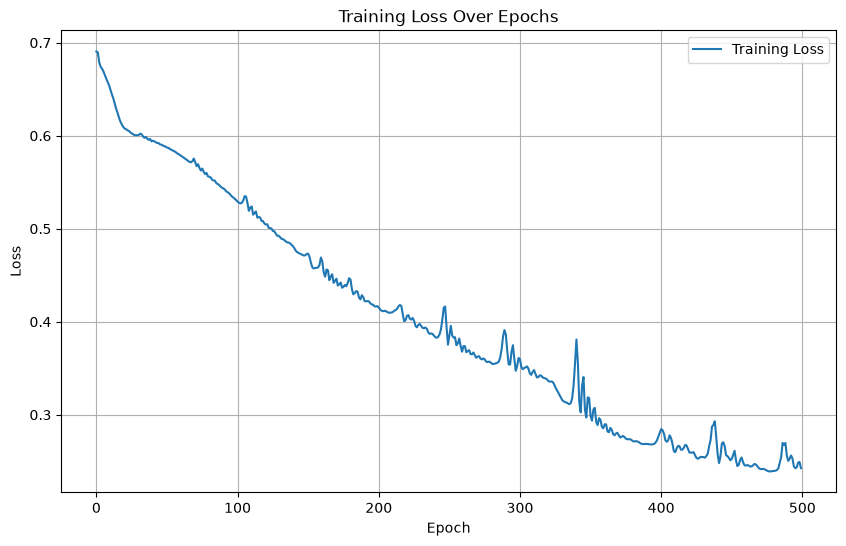

In [14]:
# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

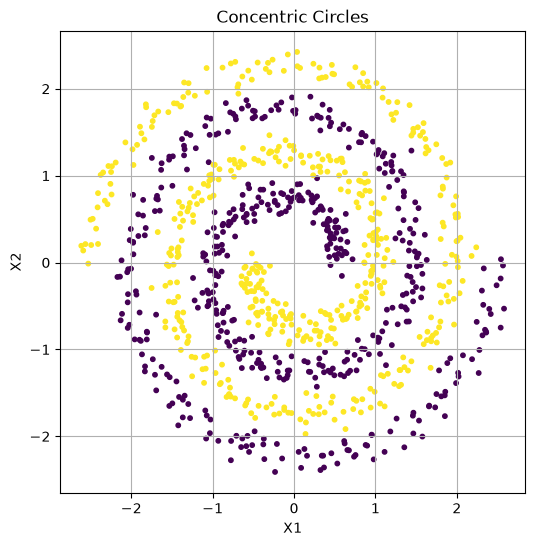

In [15]:
def plot_dataset(X, y, title="Dataset"):
   # Convert tensors to numpy for plotting
   X_np = X.detach().cpu().numpy()
   y_np = y.detach().cpu().numpy()

   plt.figure(figsize=(6, 6))
   plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=10)
   plt.title(title)
   plt.xlabel("X1")
   plt.ylabel("X2")
   plt.grid(True)
   plt.show()


# Example usage
X, y = make_spirals()
plot_dataset(X, y, title="Concentric Circles")